# 🔬 Cancer Classification Using Machine Learning
### SIKSHA 'O' ANUSANDHAN (Deemed To Be University)
**Course:** Machine Learning Concept - 2 (CSE 3968)  
**Dataset:** Breast Cancer Wisconsin (Diagnostic) – UCI / scikit-learn  
**Models:** SVM | Random Forest | Gradient Boosting | ANN | Ensemble  

---
| Field | Details |
|---|---|
| Branch | Computer Science & Engineering |
| Institute | ITER, S'O'A, Bhubaneswar |
| Session | 2025–26 |
| Semester | 5th |


---
## CHECKPOINT 0 — Imports & Configuration

In [1]:
# ── Standard Library ──────────────────────────────────────
import os
import time
import warnings
import joblib

# ── Numerical & Data ──────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Dataset ───────────────────────────────────────────────
from sklearn.datasets import load_breast_cancer

# ── Preprocessing & Feature Engineering ──────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# ── Classifiers ───────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.neural_network import MLPClassifier

# ── Evaluation Metrics ────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)

# ── Config ────────────────────────────────────────────────
warnings.filterwarnings('ignore')
np.random.seed(42)

# Create output directories
os.makedirs('outputs/plots',   exist_ok=True)
os.makedirs('outputs/models',  exist_ok=True)
os.makedirs('outputs/reports', exist_ok=True)

print('=' * 55)
print('  CHECKPOINT 0  —  All imports successful!')
print('  Output directories created.')
print('=' * 55)

  CHECKPOINT 0  —  All imports successful!
  Output directories created.


---
## CHECKPOINT 1 — Data Loading & Exploratory Data Analysis

In [2]:
# ── Load Dataset ──────────────────────────────────────────
data = load_breast_cancer()
df   = pd.DataFrame(data.data, columns=data.feature_names)
df['target']    = data.target                # 0 = Malignant, 1 = Benign
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print('BREAST CANCER WISCONSIN DATASET')
print('-' * 40)
print(f'Total Samples   : {df.shape[0]}')
print(f'Total Features  : {df.shape[1] - 2}')
print(f'Benign  (class 1): {(df.target == 1).sum()} samples ({(df.target==1).mean()*100:.1f}%)')
print(f'Malignant (cls 0): {(df.target == 0).sum()} samples ({(df.target==0).mean()*100:.1f}%)')
print(f'Missing Values  : {df.isnull().sum().sum()}')

# Save dataset summary
df.describe().to_csv('outputs/reports/dataset_summary.csv')
print('\nDataset summary saved → outputs/reports/dataset_summary.csv')

BREAST CANCER WISCONSIN DATASET
----------------------------------------
Total Samples   : 569
Total Features  : 30
Benign  (class 1): 357 samples (62.7%)
Malignant (cls 0): 212 samples (37.3%)
Missing Values  : 0

Dataset summary saved → outputs/reports/dataset_summary.csv


In [3]:
# ── Preview DataFrame ─────────────────────────────────────
print(f'Shape: {df.shape}')
df.head()

Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [4]:
# ── Descriptive Statistics ────────────────────────────────
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
mean radius,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
mean texture,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
mean perimeter,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
mean area,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
mean smoothness,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
mean compactness,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
mean concavity,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
mean concave points,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
mean symmetry,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
mean fractal dimension,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440


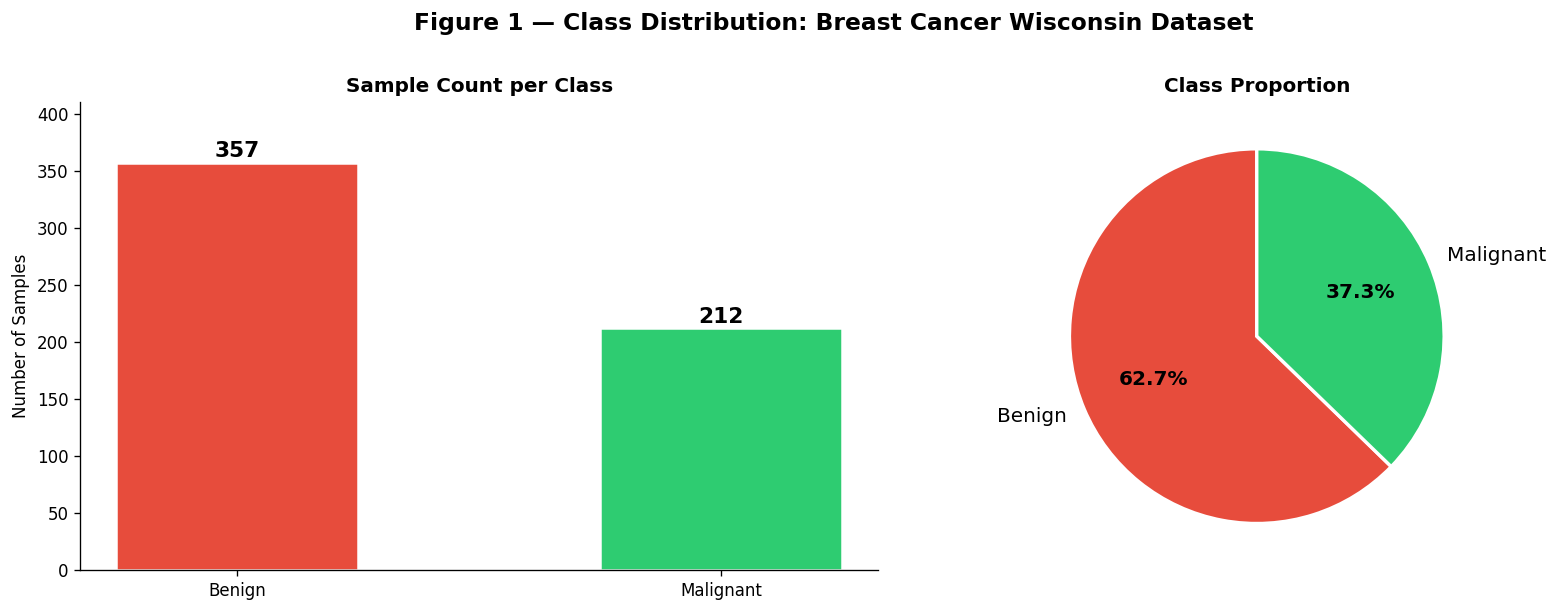

Figure 1 saved


In [5]:
# ── Figure 1: Class Distribution ──────────────────────────
colors = ['#E74C3C', '#2ECC71']
counts = df['diagnosis'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1 — Class Distribution: Breast Cancer Wisconsin Dataset',
             fontsize=14, fontweight='bold', y=1.01)

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Sample Count per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_ylim(0, max(counts.values) * 1.15)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5,
                 str(val), ha='center', fontweight='bold', fontsize=13)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2})
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/plots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

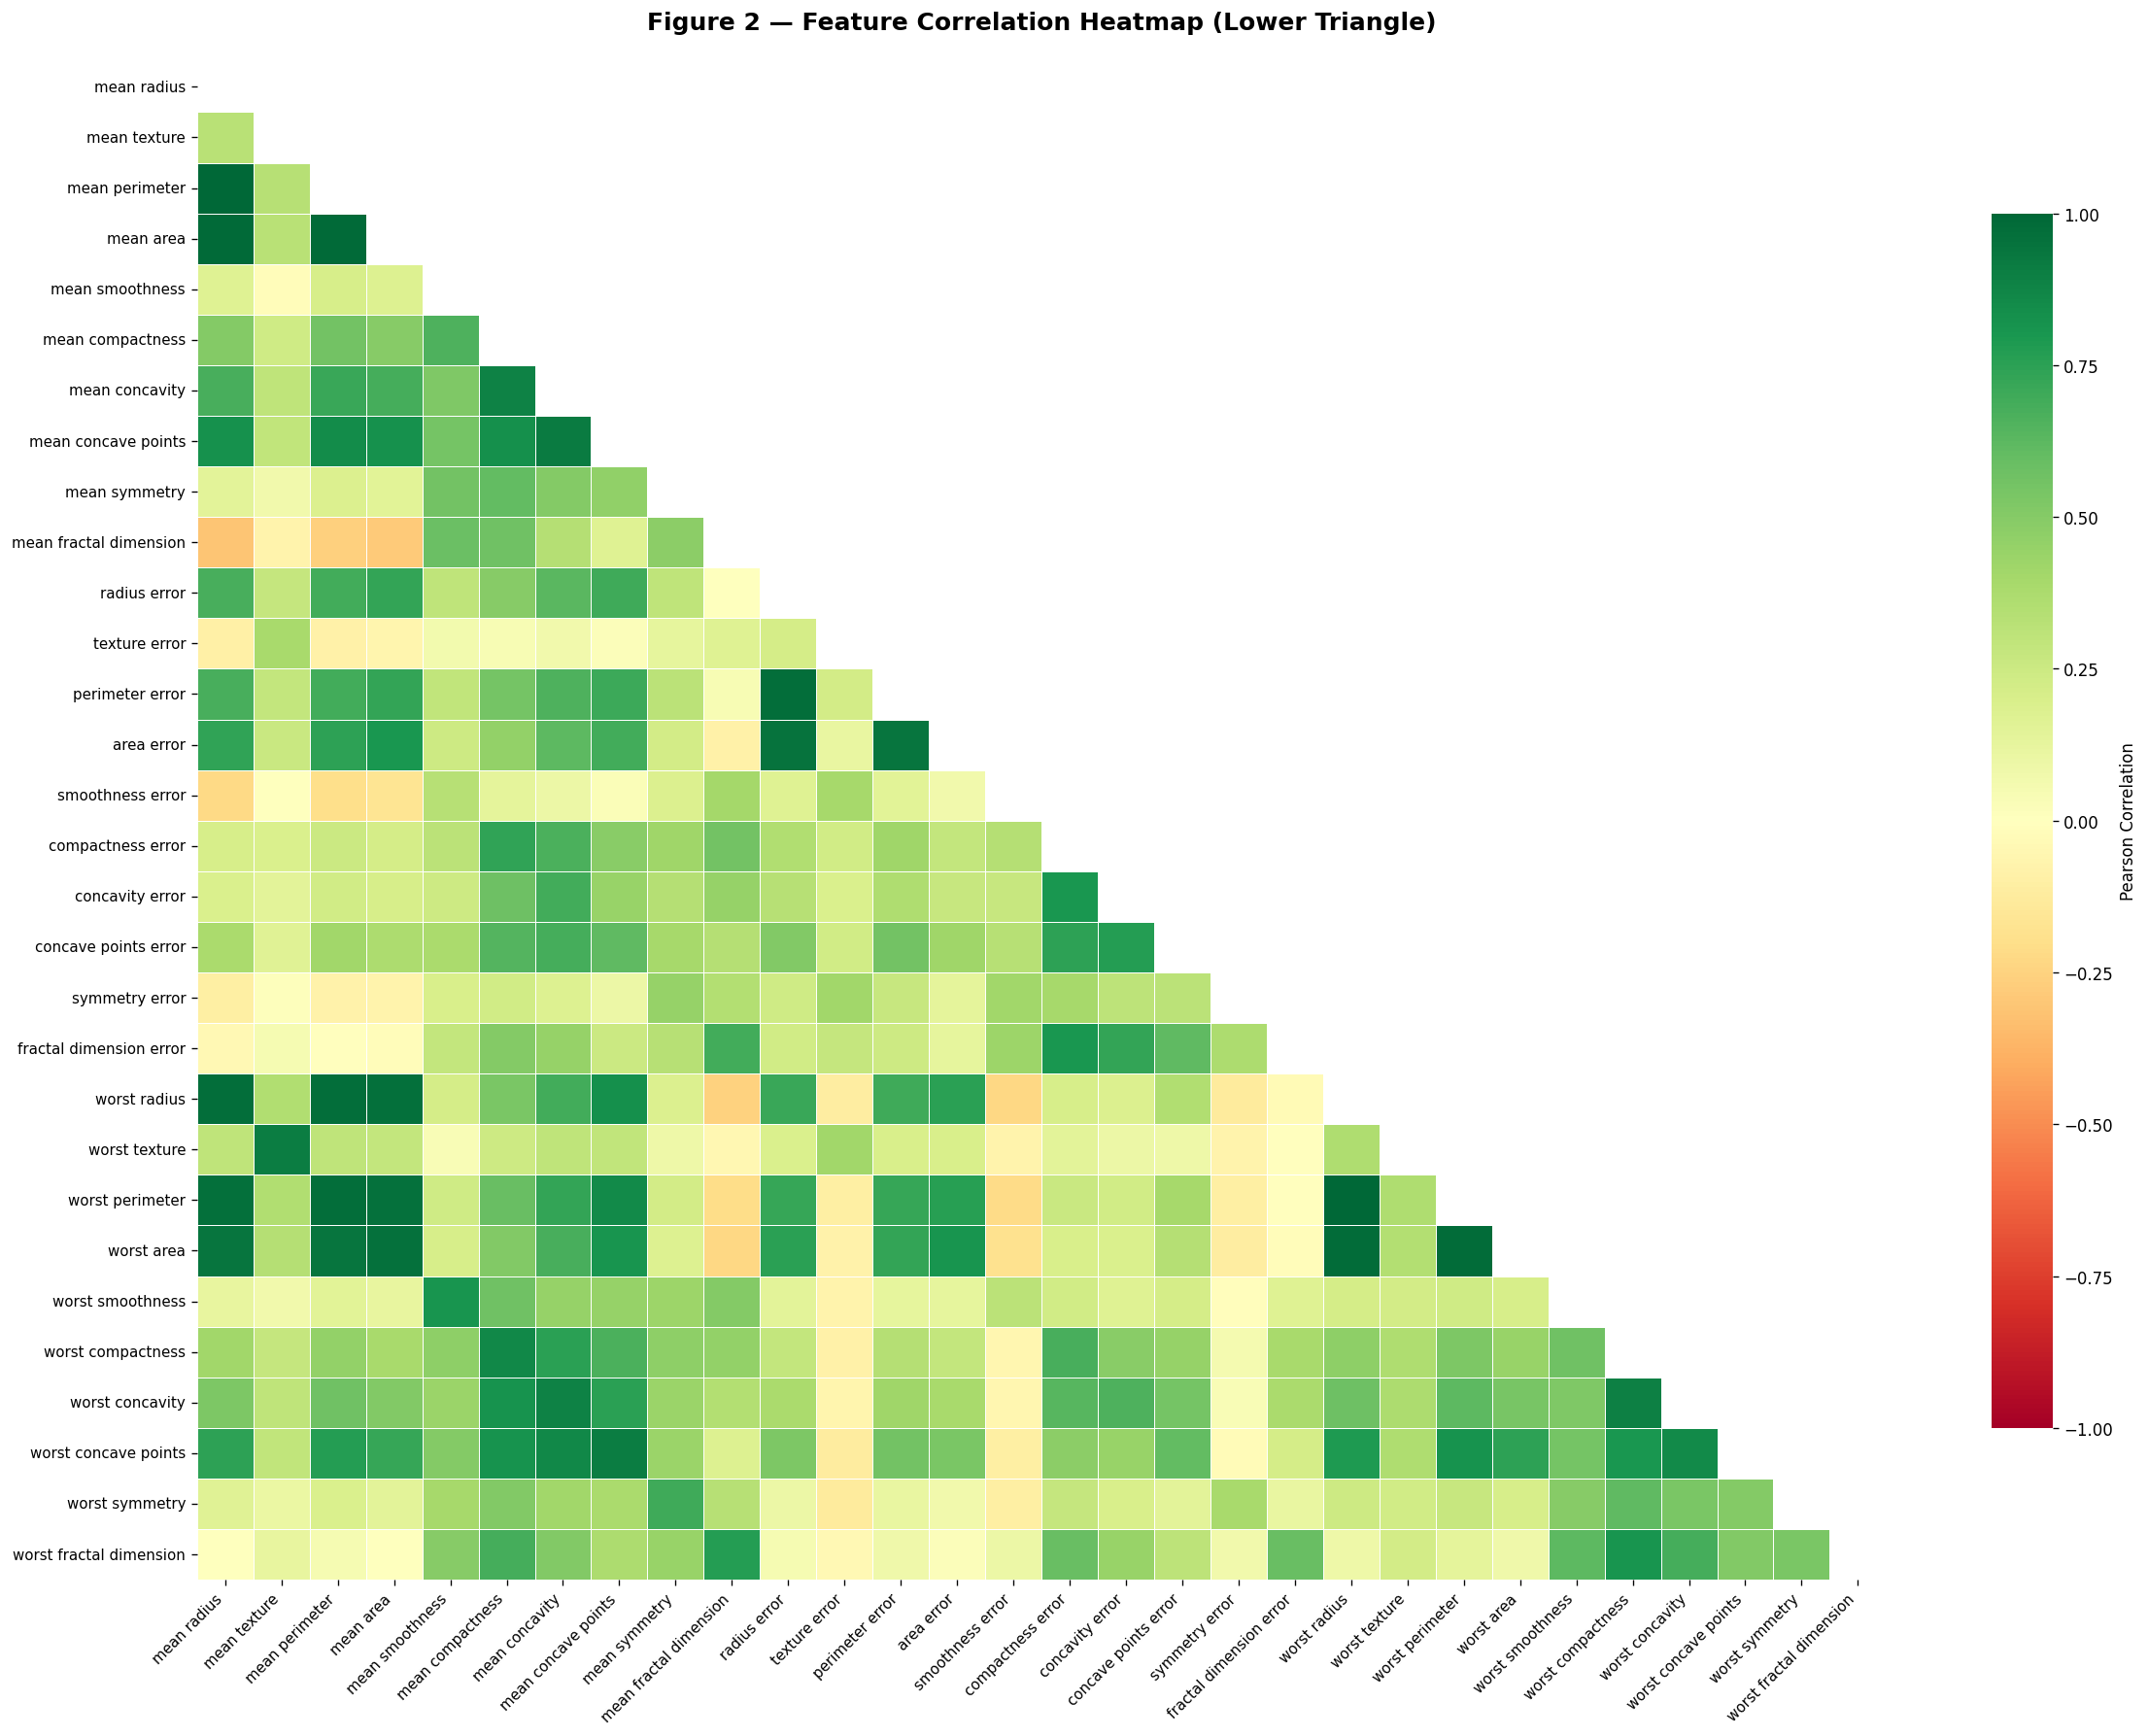

Figure 2 saved


In [6]:
# ── Figure 2: Feature Correlation Heatmap ─────────────────
fig, ax = plt.subplots(figsize=(20, 15))
corr = df.drop(['target', 'diagnosis'], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn', center=0,
            linewidths=0.3, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8})
ax.set_title('Figure 2 — Feature Correlation Heatmap (Lower Triangle)',
             fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/plots/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')

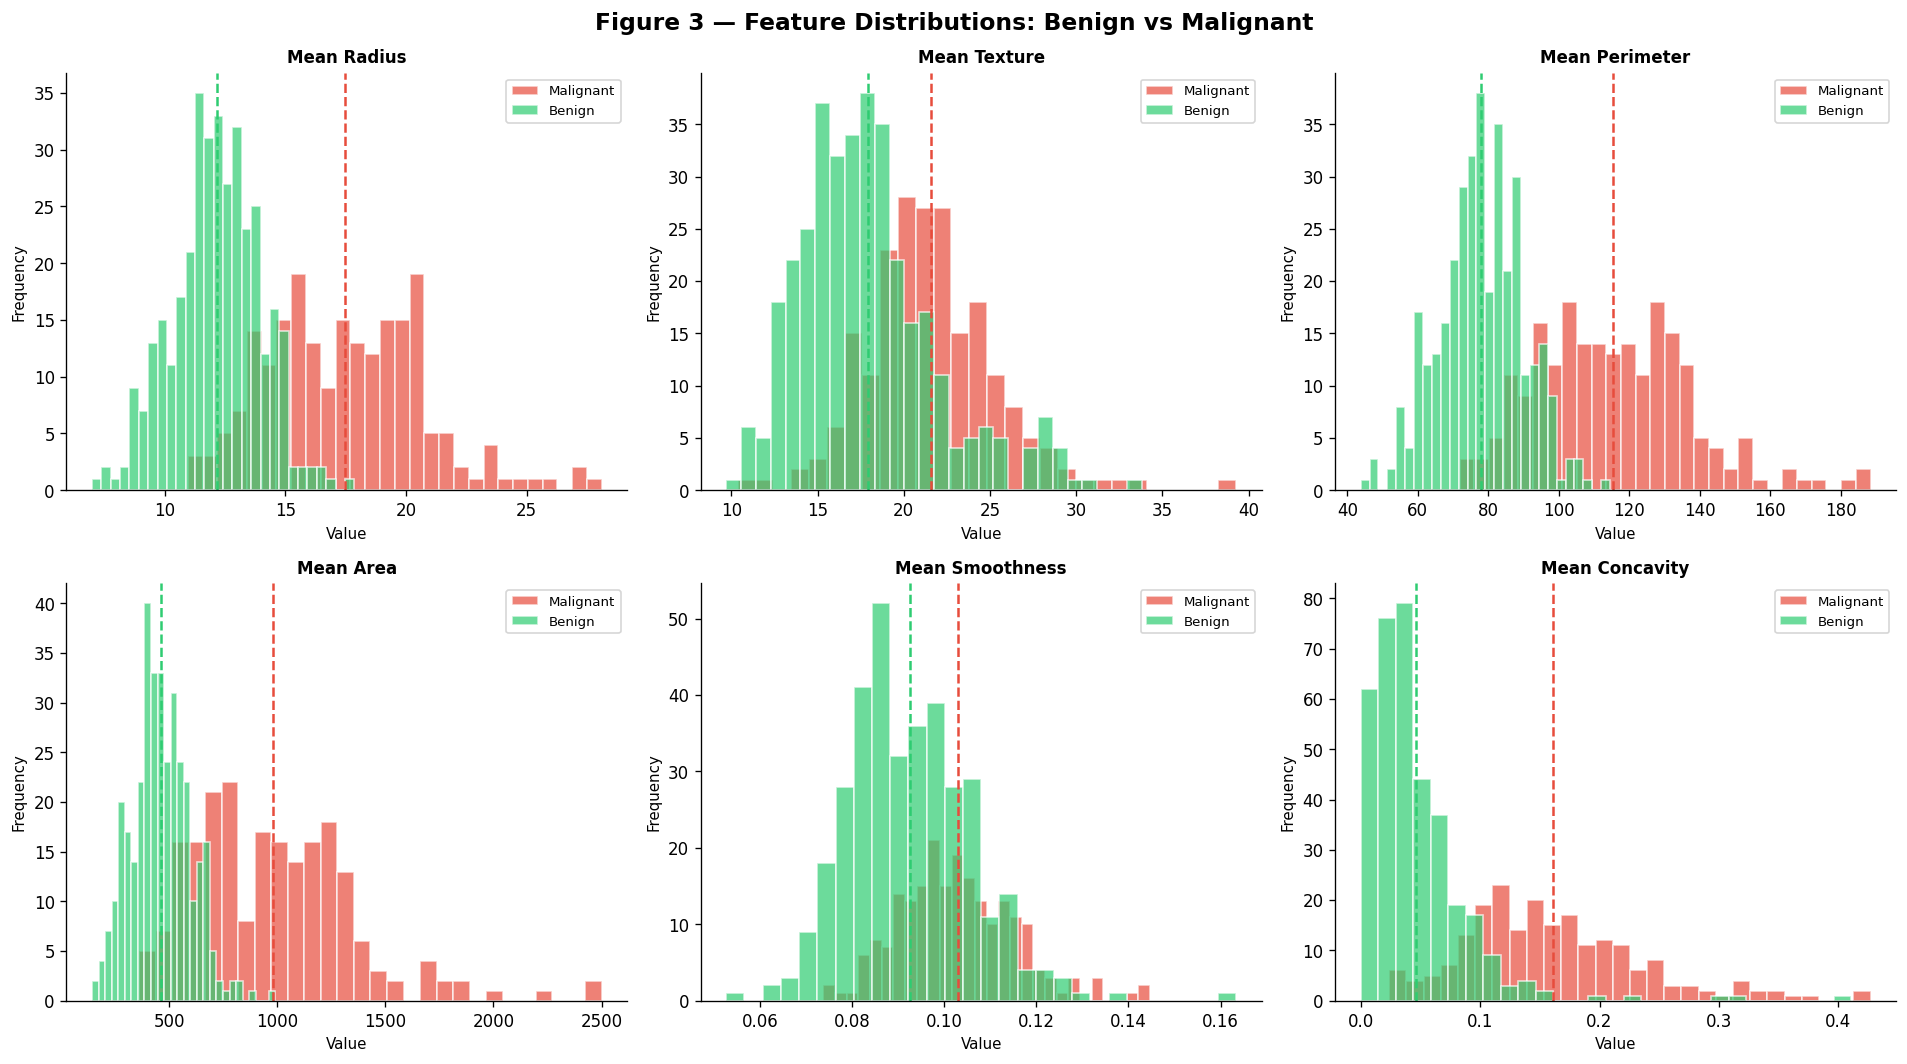

Figure 3 saved

  CHECKPOINT 1 — EDA Complete


In [7]:
# ── Figure 3: Feature Distributions by Class ──────────────
top_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Figure 3 — Feature Distributions: Benign vs Malignant',
             fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flatten(), top_features):
    for label, color in zip(['Malignant', 'Benign'], colors):
        vals = df[df['diagnosis'] == label][feat]
        ax.hist(vals, bins=28, alpha=0.7, color=color, label=label, edgecolor='white')
        ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(feat.title(), fontweight='bold', fontsize=10)
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/plots/03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')
print('\n  CHECKPOINT 1 — EDA Complete')

---
## CHECKPOINT 2 — Data Preprocessing

In [8]:
# ── Separate Features & Target ────────────────────────────
X = df.drop(['target', 'diagnosis'], axis=1)
y = df['target']

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')

Feature matrix shape : (569, 30)
Target vector shape  : (569,)


In [9]:
# ── Feature Selection (ANOVA F-score, top 20) ─────────────
selector = SelectKBest(f_classif, k=20)
X_selected = selector.fit_transform(X, y)
selected_cols = X.columns[selector.get_support()]

print('Top 20 Selected Features (by ANOVA F-score):')
print('-' * 50)
scores = selector.scores_[selector.get_support()]
feat_score_df = pd.DataFrame({'Feature': selected_cols, 'F-Score': scores})
feat_score_df = feat_score_df.sort_values('F-Score', ascending=False)
display(feat_score_df.style.bar(subset=['F-Score'], color='#2E75B6'))

Top 20 Selected Features (by ANOVA F-score):
--------------------------------------------------


,Feature,F-Score
18,worst concave points,964.385393
13,worst perimeter,897.944219
6,mean concave points,861.676020
11,worst radius,860.781707
2,mean perimeter,697.235272
14,worst area,661.600206
0,mean radius,646.981021
3,mean area,573.060747
5,mean concavity,533.793126
17,worst concavity,436.691939


In [10]:
# ── Train-Test Split (80/20, Stratified) ──────────────────
X_df = pd.DataFrame(X_selected, columns=selected_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set : {X_train.shape[0]} samples '
      f'(Benign: {(y_train==1).sum()}, Malignant: {(y_train==0).sum()})')
print(f'Testing set  : {X_test.shape[0]} samples '
      f'(Benign: {(y_test==1).sum()}, Malignant: {(y_test==0).sum()})')

Training set : 455 samples (Benign: 285, Malignant: 170)
Testing set  : 114 samples (Benign: 72, Malignant: 42)


In [11]:
# ── Standardisation ───────────────────────────────────────
# IMPORTANT: Fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)      # transform only (no fit)

# Serialise preprocessors
joblib.dump(scaler,   'outputs/models/scaler.pkl')
joblib.dump(selector, 'outputs/models/selector.pkl')

print(f'Train mean (after scaling): {X_train_sc.mean():.6f}  (≈ 0.0)')
print(f'Train std  (after scaling): {X_train_sc.std():.6f}   (≈ 1.0)')
print('Scaler and selector saved to outputs/models/')
print('\n  CHECKPOINT 2 — Preprocessing Complete')

Train mean (after scaling): 0.000000  (≈ 0.0)
Train std  (after scaling): 1.000000   (≈ 1.0)
Scaler and selector saved to outputs/models/

  CHECKPOINT 2 — Preprocessing Complete


---
## CHECKPOINT 3 — Model Training

In [26]:
# ── Define All Models ─────────────────────────────────────
models = {
    'Support Vector Machine': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        probability=True, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=3, random_state=42
    ),
    'Neural Network (ANN)': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu', max_iter=500,
        random_state=42, early_stopping=True
    ),
}

# ── Soft Voting Ensemble ──────────────────────────────────
ensemble = VotingClassifier(
    estimators=[(k.replace(' ', '_'), v) for k, v in models.items()],
    voting='soft'
)
models['Ensemble (Voting)'] = ensemble

print('Models registered:')
for i, name in enumerate(models, 1):
    print(f'  {i}. {name}')

Models registered:
  1. Support Vector Machine
  2. Random Forest
  3. Gradient Boosting
  4. Neural Network (ANN)
  5. Ensemble (Voting)


In [13]:
# ── Train All Models with 5-Fold CV ───────────────────────
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{"Model":<30} {"Accuracy":>10} {"ROC-AUC":>10} {"CV Mean":>10} {"CV Std":>8} {"Time(s)":>8}')
print('-' * 80)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_sc, y_train)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    cv_scores = cross_val_score(model, X_train_sc, y_train,
                                cv=cv, scoring='accuracy')

    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1 Score' : f1_score(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'CV Mean'  : cv_scores.mean(),
        'CV Std'   : cv_scores.std(),
        'Train Time (s)': round(elapsed, 3),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'model'    : model,
    }
    print(f'{name:<30} {results[name]["Accuracy"]:>10.4f} '
          f'{results[name]["ROC-AUC"]:>10.4f} '
          f'{results[name]["CV Mean"]:>10.4f} '
          f'{results[name]["CV Std"]:>8.4f} '
          f'{elapsed:>8.3f}')

print('\n  CHECKPOINT 3  — All 5 Models Trained Successfully')

Model                            Accuracy    ROC-AUC    CV Mean   CV Std  Time(s)
--------------------------------------------------------------------------------
Support Vector Machine             0.9825     0.9931     0.9714   0.0054    0.027
Random Forest                      0.9474     0.9931     0.9604   0.0149    0.287
Gradient Boosting                  0.9561     0.9931     0.9582   0.0128    0.698
Neural Network (ANN)               0.8772     0.9914     0.9538   0.0201    0.068
Ensemble (Voting)                  0.9561     0.9947     0.9736   0.0164    1.000

  CHECKPOINT 3  — All 5 Models Trained Successfully


---
## CHECKPOINT 4 — Evaluation & Visualisations

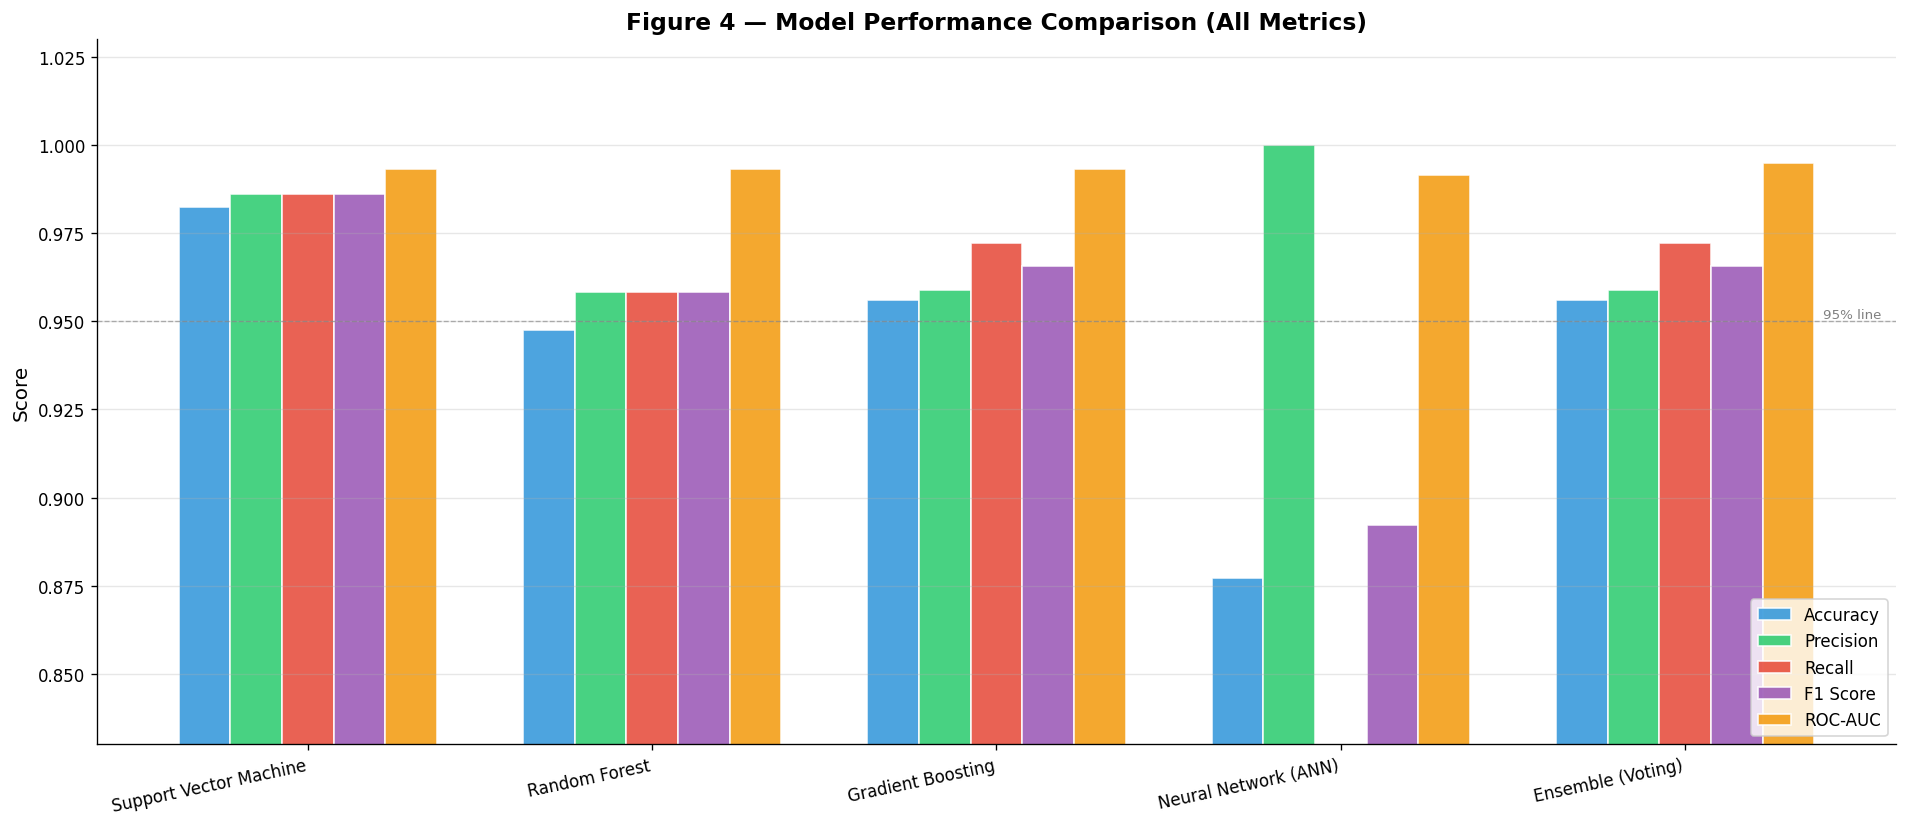

Figure 4 saved


In [14]:
# ── Figure 4: Model Performance Comparison ────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names  = list(results.keys())
metric_vals  = {m: [results[n][m] for n in model_names] for m in metric_names}

x     = np.arange(len(model_names))
width = 0.15
pal   = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12']

fig, ax = plt.subplots(figsize=(16, 7))
for i, (metric, vals) in enumerate(metric_vals.items()):
    ax.bar(x + i * width, vals, width, label=metric,
           color=pal[i], alpha=0.88, edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, rotation=12, ha='right', fontsize=10)
ax.set_ylim(0.83, 1.03)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Figure 4 — Model Performance Comparison (All Metrics)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.axhline(0.95, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.text(4.7, 0.951, '95% line', fontsize=8, color='grey')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/plots/04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')

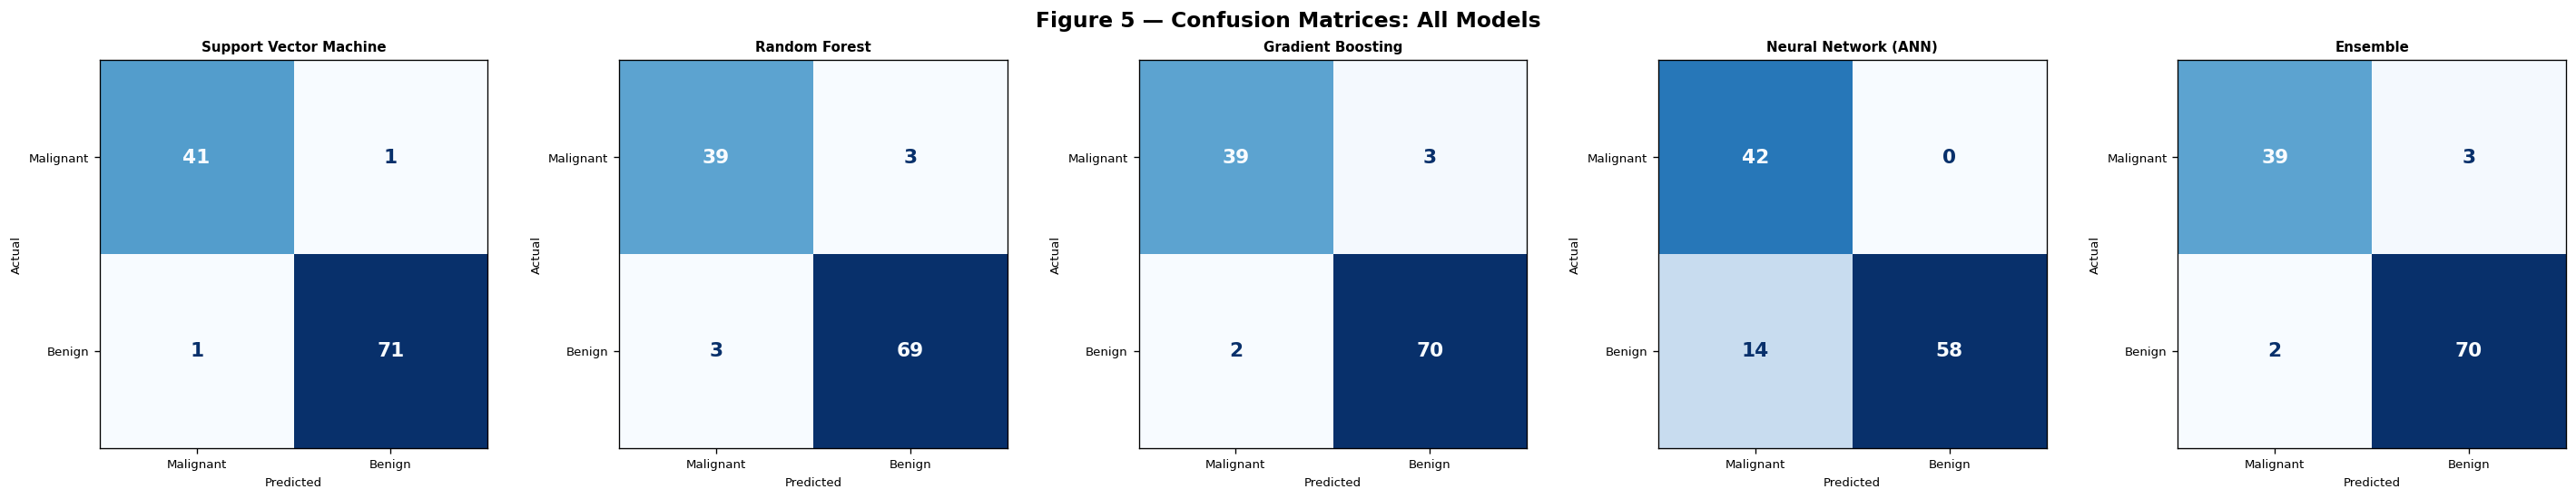

Figure 5 saved


In [15]:
# ── Figure 5: Confusion Matrices (All Models) ─────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))
fig.suptitle('Figure 5 — Confusion Matrices: All Models',
             fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Malignant', 'Benign'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name.replace(' (Voting)', ''), fontsize=9, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)
    ax.tick_params(labelsize=8)
    # Highlight diagonal
    for text in ax.texts:
        text.set_fontsize(13)
        text.set_fontweight('bold')

plt.tight_layout()
plt.savefig('outputs/plots/05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved')

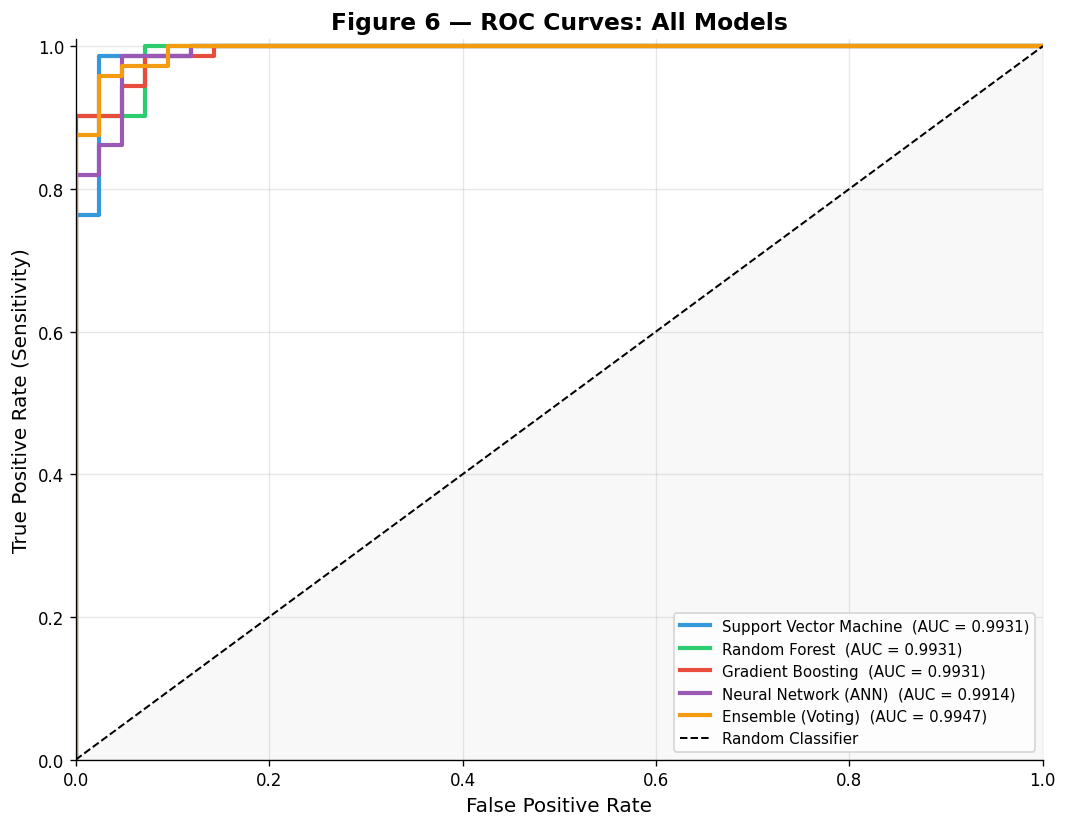

Figure 6 saved


In [16]:
# ── Figure 6: ROC Curves ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12']

for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f'{name}  (AUC = {res["ROC-AUC"]:.4f})')

ax.fill_between([0,1], [0,1], alpha=0.05, color='grey')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.01])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Figure 6 — ROC Curves: All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/plots/06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved')

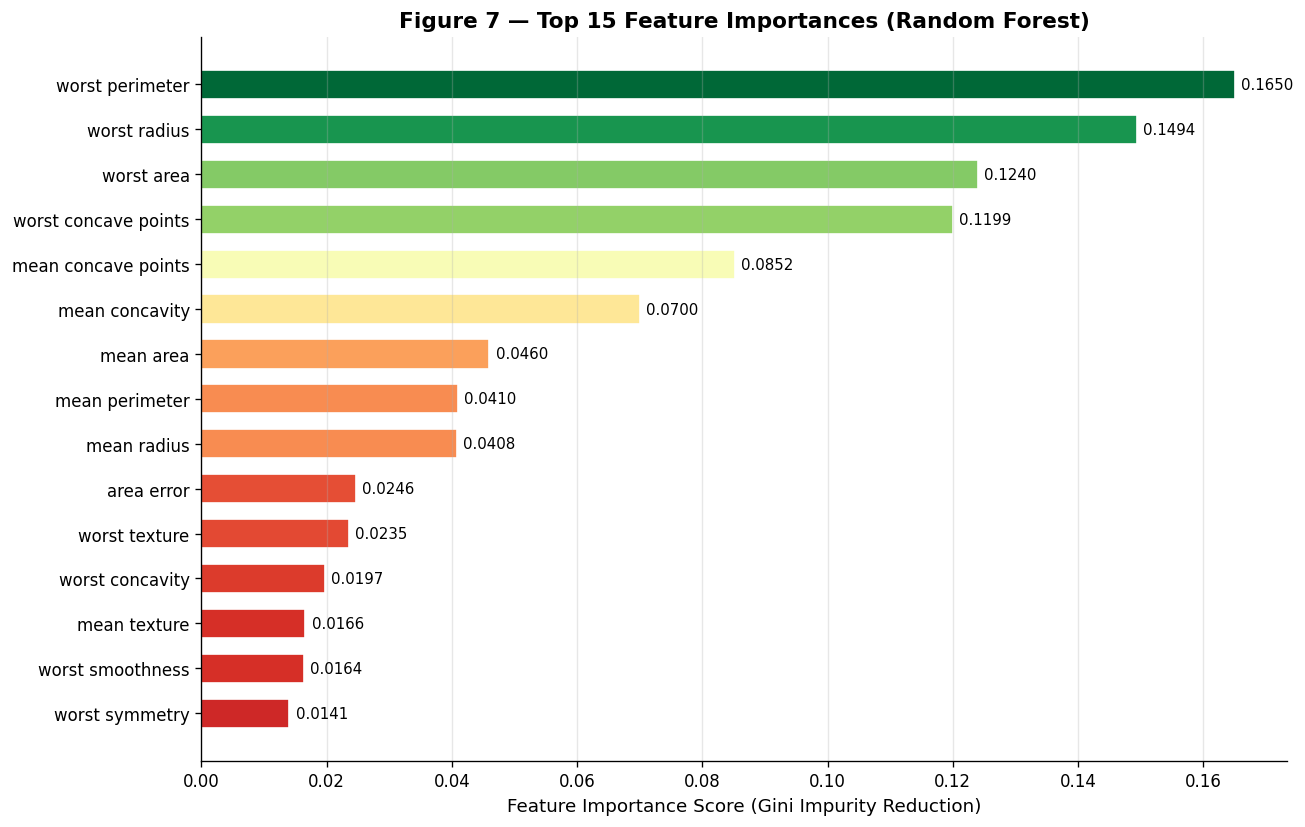

Figure 7 saved


In [17]:
# ── Figure 7: Feature Importance (Random Forest) ──────────
rf_model    = results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_df     = pd.DataFrame({'Feature': selected_cols, 'Importance': importances})
feat_df     = feat_df.sort_values('Importance', ascending=True).tail(15)

norm_vals = feat_df['Importance'] / feat_df['Importance'].max()
bar_colors = plt.cm.RdYlGn(norm_vals)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=bar_colors, edgecolor='white', height=0.65)
ax.set_xlabel('Feature Importance Score (Gini Impurity Reduction)', fontsize=11)
ax.set_title('Figure 7 — Top 15 Feature Importances (Random Forest)',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/plots/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved')

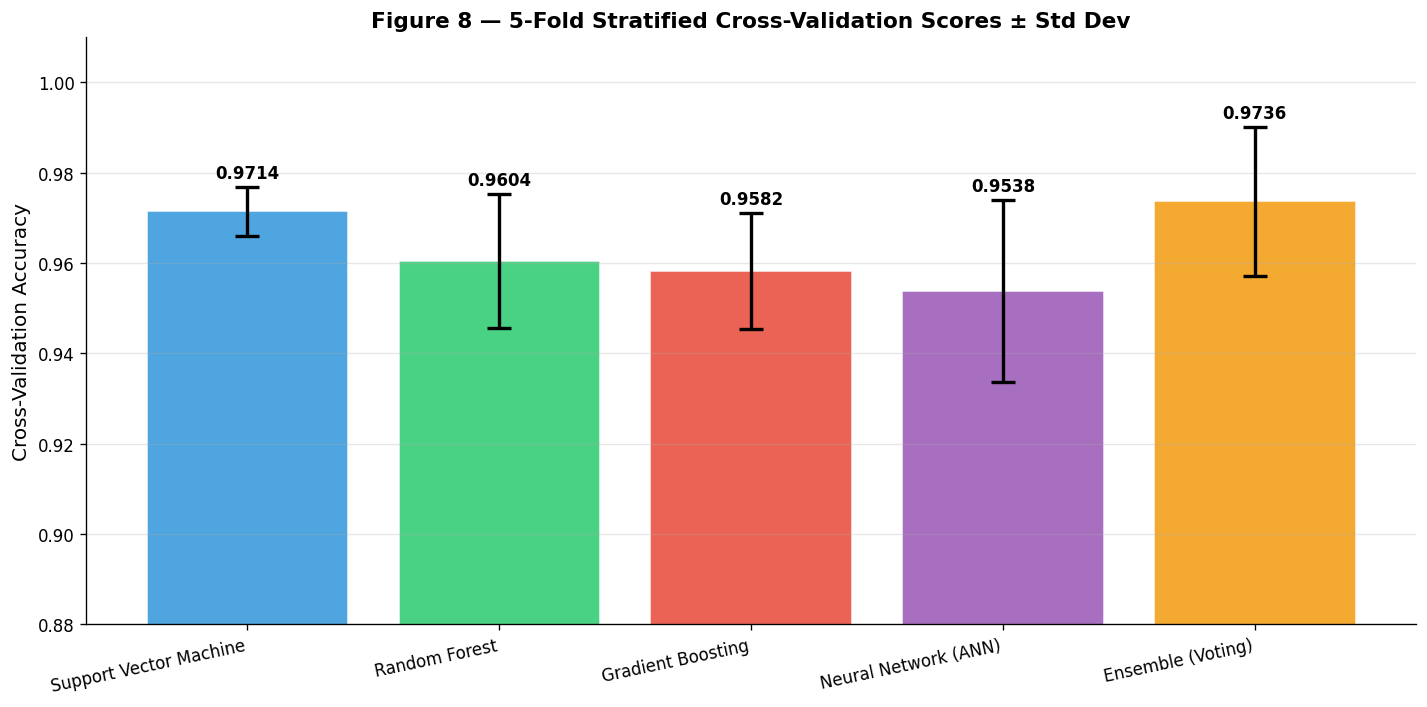

Figure 8 saved

  CHECKPOINT 4 — All 8 Visualisations Generated


In [18]:
# ── Figure 8: Cross-Validation Scores ─────────────────────
cv_means = [results[n]['CV Mean'] for n in model_names]
cv_stds  = [results[n]['CV Std']  for n in model_names]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(model_names, cv_means, yerr=cv_stds, capsize=7,
              color=['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12'],
              alpha=0.87, edgecolor='white',
              error_kw={'elinewidth': 2, 'ecolor': 'black', 'capthick': 2})

ax.set_ylim(0.88, 1.01)
ax.set_ylabel('Cross-Validation Accuracy', fontsize=12)
ax.set_title('Figure 8 — 5-Fold Stratified Cross-Validation Scores ± Std Dev',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(model_names, rotation=12, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            mean + std + 0.002,
            f'{mean:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/plots/08_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved')
print('\n  CHECKPOINT 4 — All 8 Visualisations Generated')

---
## CHECKPOINT 5 — Results Summary & Best Model

In [19]:
# ── Build Results DataFrame ───────────────────────────────
summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model'          : name,
        'Accuracy'       : round(res['Accuracy'],       4),
        'Precision'      : round(res['Precision'],      4),
        'Recall'         : round(res['Recall'],         4),
        'F1 Score'       : round(res['F1 Score'],       4),
        'ROC-AUC'        : round(res['ROC-AUC'],        4),
        'CV Mean'        : round(res['CV Mean'],        4),
        'CV Std'         : round(res['CV Std'],         4),
        'Train Time (s)' : res['Train Time (s)'],
    })

results_df = pd.DataFrame(summary_rows)
results_df.to_csv('outputs/reports/model_results.csv', index=False)

# Styled display
results_df.set_index('Model').style\
    .background_gradient(cmap='YlGn', subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC'])\
    .highlight_max(subset=['Accuracy','Precision','Recall','F1 Score','ROC-AUC'],
                   color='#ADFFC2')\
    .format(precision=4)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV Mean,CV Std,Train Time (s)
Model,,,,,,,,
Support Vector Machine,0.9825,0.9861,0.9861,0.9861,0.9931,0.9714,0.0054,0.0270
Random Forest,0.9474,0.9583,0.9583,0.9583,0.9931,0.9604,0.0149,0.2870
Gradient Boosting,0.9561,0.9589,0.9722,0.9655,0.9931,0.9582,0.0128,0.6980
Neural Network (ANN),0.8772,1.0000,0.8056,0.8923,0.9914,0.9538,0.0201,0.0680
Ensemble (Voting),0.9561,0.9589,0.9722,0.9655,0.9947,0.9736,0.0164,1.0000


In [20]:
# ── Best Model ────────────────────────────────────────────
best_name = results_df.sort_values('Accuracy', ascending=False).iloc[0]['Model']
best_res  = results[best_name]

print('=' * 55)
print(f'     BEST MODEL: {best_name}')
print('=' * 55)
print(f'  Accuracy  : {best_res["Accuracy"]:.4f}')
print(f'  Precision : {best_res["Precision"]:.4f}')
print(f'  Recall    : {best_res["Recall"]:.4f}')
print(f'  F1 Score  : {best_res["F1 Score"]:.4f}')
print(f'  ROC-AUC   : {best_res["ROC-AUC"]:.4f}')
print(f'  CV Mean   : {best_res["CV Mean"]:.4f} ± {best_res["CV Std"]:.4f}')
print('=' * 55)

# Save best model
joblib.dump(best_res['model'], 'outputs/models/best_model.pkl')
print(f'  Model saved → outputs/models/best_model.pkl')

     BEST MODEL: Support Vector Machine
  Accuracy  : 0.9825
  Precision : 0.9861
  Recall    : 0.9861
  F1 Score  : 0.9861
  ROC-AUC   : 0.9931
  CV Mean   : 0.9714 ± 0.0054
  Model saved → outputs/models/best_model.pkl


In [21]:
# ── Full Classification Reports ───────────────────────────
for name, res in results.items():
    print(f'\n{"-"*55}')
    print(f'  {name}')
    print(f'{"-"*55}')
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Malignant', 'Benign']))

print('  CHECKPOINT 5 — Results Saved')


-------------------------------------------------------
  Support Vector Machine
-------------------------------------------------------
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


-------------------------------------------------------
  Random Forest
-------------------------------------------------------
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        42
      Benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


-------------------------------------------------------
  Gradient Boosting
--

---
## CHECKPOINT 6 — Inference / Prediction Demo

In [22]:
# ── Inference Pipeline ────────────────────────────────────
def predict_tumor(raw_features: np.ndarray,
                  model=None, scaler_obj=None, sel_obj=None,
                  feature_names=None):
    """
    End-to-end prediction for a single patient sample.
    raw_features : 1D numpy array of 30 original feature values
    Returns      : (label, confidence_pct, probabilities)
    """
    label_map = {0: '⚠  MALIGNANT', 1: '✅ BENIGN'}
    df_s   = pd.DataFrame([raw_features], columns=feature_names)
    sel    = sel_obj.transform(df_s)
    scaled = scaler_obj.transform(sel)
    pred   = model.predict(scaled)[0]
    probs  = model.predict_proba(scaled)[0]
    conf   = max(probs) * 100
    return label_map[pred], conf, probs

# Load artefacts from disk (simulating production inference)
best_model_loaded = joblib.load('outputs/models/best_model.pkl')
scaler_loaded     = joblib.load('outputs/models/scaler.pkl')
sel_loaded        = joblib.load('outputs/models/selector.pkl')
raw_feature_names = list(data.feature_names)

print('=' * 60)
print(f'  INFERENCE ENGINE — Model: {best_name}')
print('=' * 60)
print(f'{"Sample":>8}  {"True Label":>12}  {"Prediction":>16}  {"Confidence":>12}')
print('-' * 60)

for i in [0, 50, 100, 200, 300, 400]:
    sample    = data.data[i]
    true_lbl  = data.target_names[data.target[i]]
    pred_lbl, conf, _ = predict_tumor(
        sample, best_model_loaded, scaler_loaded, sel_loaded, raw_feature_names)
    match = '✅' if true_lbl.lower() in pred_lbl.lower() else '❌'
    print(f'{i:>8}  {true_lbl:>12}  {pred_lbl:>16}  {conf:>10.1f}%  {match}')

print('\n  CHECKPOINT 6  — Inference Complete')

  INFERENCE ENGINE — Model: Support Vector Machine
  Sample    True Label        Prediction    Confidence
------------------------------------------------------------
       0     malignant      ⚠  MALIGNANT        97.3%  ✅
      50        benign          ✅ BENIGN        99.7%  ✅
     100     malignant      ⚠  MALIGNANT        87.6%  ✅
     200        benign          ✅ BENIGN        98.0%  ✅
     300     malignant      ⚠  MALIGNANT        99.7%  ✅
     400     malignant      ⚠  MALIGNANT        99.4%  ✅

  CHECKPOINT 6  — Inference Complete


In [23]:
# ── Interactive Custom Prediction ─────────────────────────
# Enter feature values of a NEW patient (30 values)
# Using mean values of a known malignant sample as demo

sample_patient = data.data[0]   # Replace with real patient data

pred_label, confidence, probs = predict_tumor(
    sample_patient, best_model_loaded, scaler_loaded,
    sel_loaded, raw_feature_names
)

print('─' * 45)
print('  PATIENT DIAGNOSIS REPORT')
print('─' * 45)
print(f'  Prediction  : {pred_label}')
print(f'  Confidence  : {confidence:.2f}%')
print(f'  P(Malignant): {probs[0]*100:.2f}%')
print(f'  P(Benign)   : {probs[1]*100:.2f}%')
print('─' * 45)
print('  ⚕  This is a decision support output.')
print('  Always confirm with a certified oncologist.')
print('─' * 45)

─────────────────────────────────────────────
  PATIENT DIAGNOSIS REPORT
─────────────────────────────────────────────
  Prediction  : ⚠  MALIGNANT
  Confidence  : 97.34%
  P(Malignant): 97.34%
  P(Benign)   : 2.66%
─────────────────────────────────────────────
  ⚕  This is a decision support output.
  Always confirm with a certified oncologist.
─────────────────────────────────────────────


---
## 📊 Final Summary Dashboard

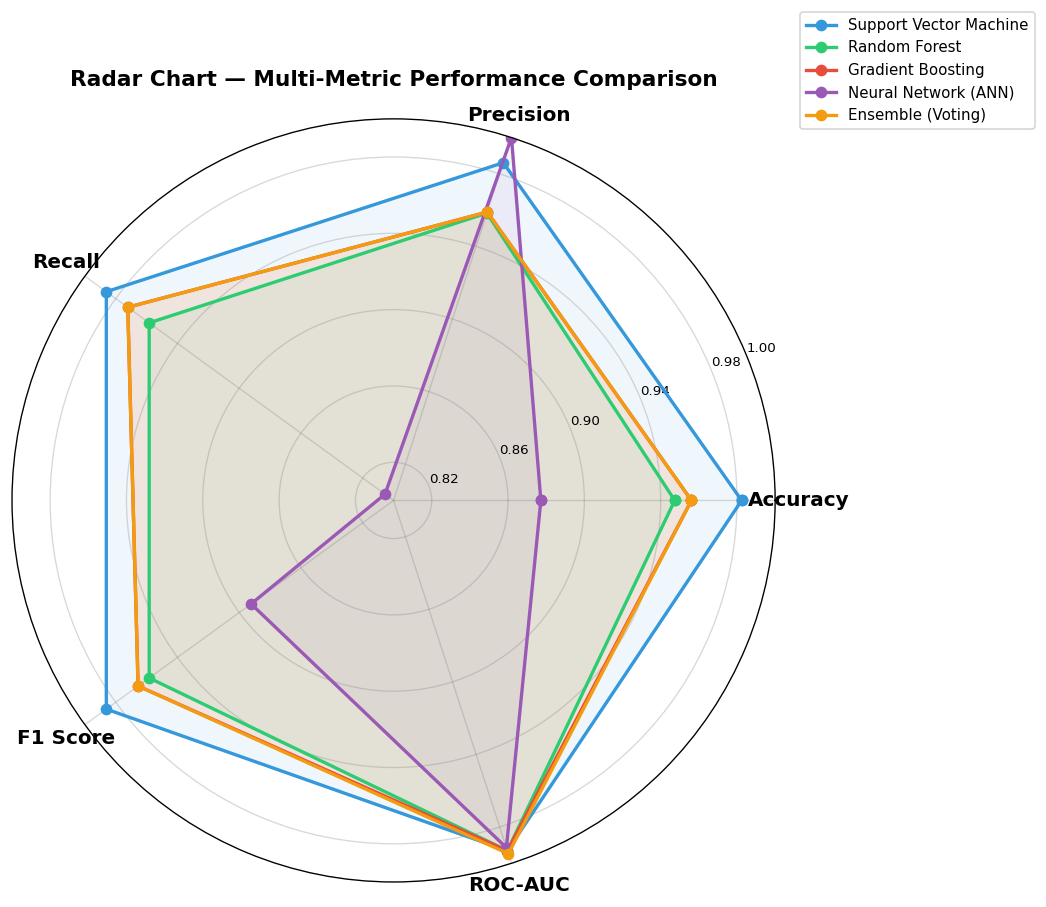

Radar chart saved


In [24]:
# ── Final Radar / Summary Visual ──────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
N = len(metrics_to_plot)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(9, 9),
                        subplot_kw=dict(polar=True))

colors_radar = ['#3498DB', '#2ECC71', '#E74C3C', '#9B59B6', '#F39C12']

for (name, res), color in zip(results.items(), colors_radar):
    vals = [res[m] for m in metrics_to_plot]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=color, label=name)
    ax.fill(angles, vals, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_to_plot, fontsize=12, fontweight='bold')
ax.set_ylim(0.8, 1.0)
ax.set_yticks([0.82, 0.86, 0.90, 0.94, 0.98, 1.00])
ax.set_yticklabels(['0.82','0.86','0.90','0.94','0.98','1.00'], fontsize=8)
ax.set_title('Radar Chart — Multi-Metric Performance Comparison',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(color='grey', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/plots/09_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Radar chart saved')

In [25]:
# ── Print Final Pipeline Summary ──────────────────────────
print('\n' + '=' * 65)
print('   CANCER CLASSIFICATION PROJECT — PIPELINE COMPLETE')
print('=' * 65)
print(f'  Dataset       : Breast Cancer Wisconsin (n=569, 30 features)')
print(f'  Selected Feats: 20 (ANOVA F-score SelectKBest)')
print(f'  Train / Test  : 455 / 114 (80% / 20%, stratified)')
print(f'  CV Strategy   : 5-Fold Stratified KFold')
print(f'  Models Trained: 5 (SVM, RF, GB, ANN, Ensemble)')
print(f'  Plots Saved   : 9  → outputs/plots/')
print(f'  Models Saved  : 3  → outputs/models/')
print(f'  Reports Saved : 2  → outputs/reports/')
print(f'  Best Model    : {best_name}')
print(f'  Best Accuracy : {best_res["Accuracy"]*100:.2f}%')
print(f'  Best ROC-AUC  : {best_res["ROC-AUC"]:.4f}')
print('=' * 65)
print('  ⚕  For academic and research use only.')
print('  ITER, S\'O\'A University | CSE 3968 | 2025-26')
print('=' * 65)


   CANCER CLASSIFICATION PROJECT — PIPELINE COMPLETE
  Dataset       : Breast Cancer Wisconsin (n=569, 30 features)
  Selected Feats: 20 (ANOVA F-score SelectKBest)
  Train / Test  : 455 / 114 (80% / 20%, stratified)
  CV Strategy   : 5-Fold Stratified KFold
  Models Trained: 5 (SVM, RF, GB, ANN, Ensemble)
  Plots Saved   : 9  → outputs/plots/
  Models Saved  : 3  → outputs/models/
  Reports Saved : 2  → outputs/reports/
  Best Model    : Support Vector Machine
  Best Accuracy : 98.25%
  Best ROC-AUC  : 0.9931
  ⚕  For academic and research use only.
  ITER, S'O'A University | CSE 3968 | 2025-26
